![clothing_classification](clothing_classification.png)


Fashion Forward is a new AI-based e-commerce clothing retailer.
They want to use image classification to automatically categorize new product listings, making it easier for customers to find what they're looking for. It will also assist in inventory management by quickly sorting items.

As a data scientist tasked with implementing a garment classifier, your primary objective is to develop a machine learning model capable of accurately categorizing images of clothing items into distinct garment types such as shirts, trousers, shoes, etc.

In [17]:
# Run the cells below first

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score

In [19]:
# 1. Cargar y preprocesar el dataset Fashion MNIST
print("Cargando el dataset Fashion MNIST...")
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalizar las imágenes para que los píxeles estén entre 0 y 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Añadir la dimensión del canal (Fashion MNIST es en escala de grises, así que el canal es 1)
# Las dimensiones pasarán de (28, 28) a (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Transformamos las etiquetas de números enteros (0-9) a vectores binarios
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

Cargando el dataset Fashion MNIST...


In [20]:
import matplotlib.pyplot as plt

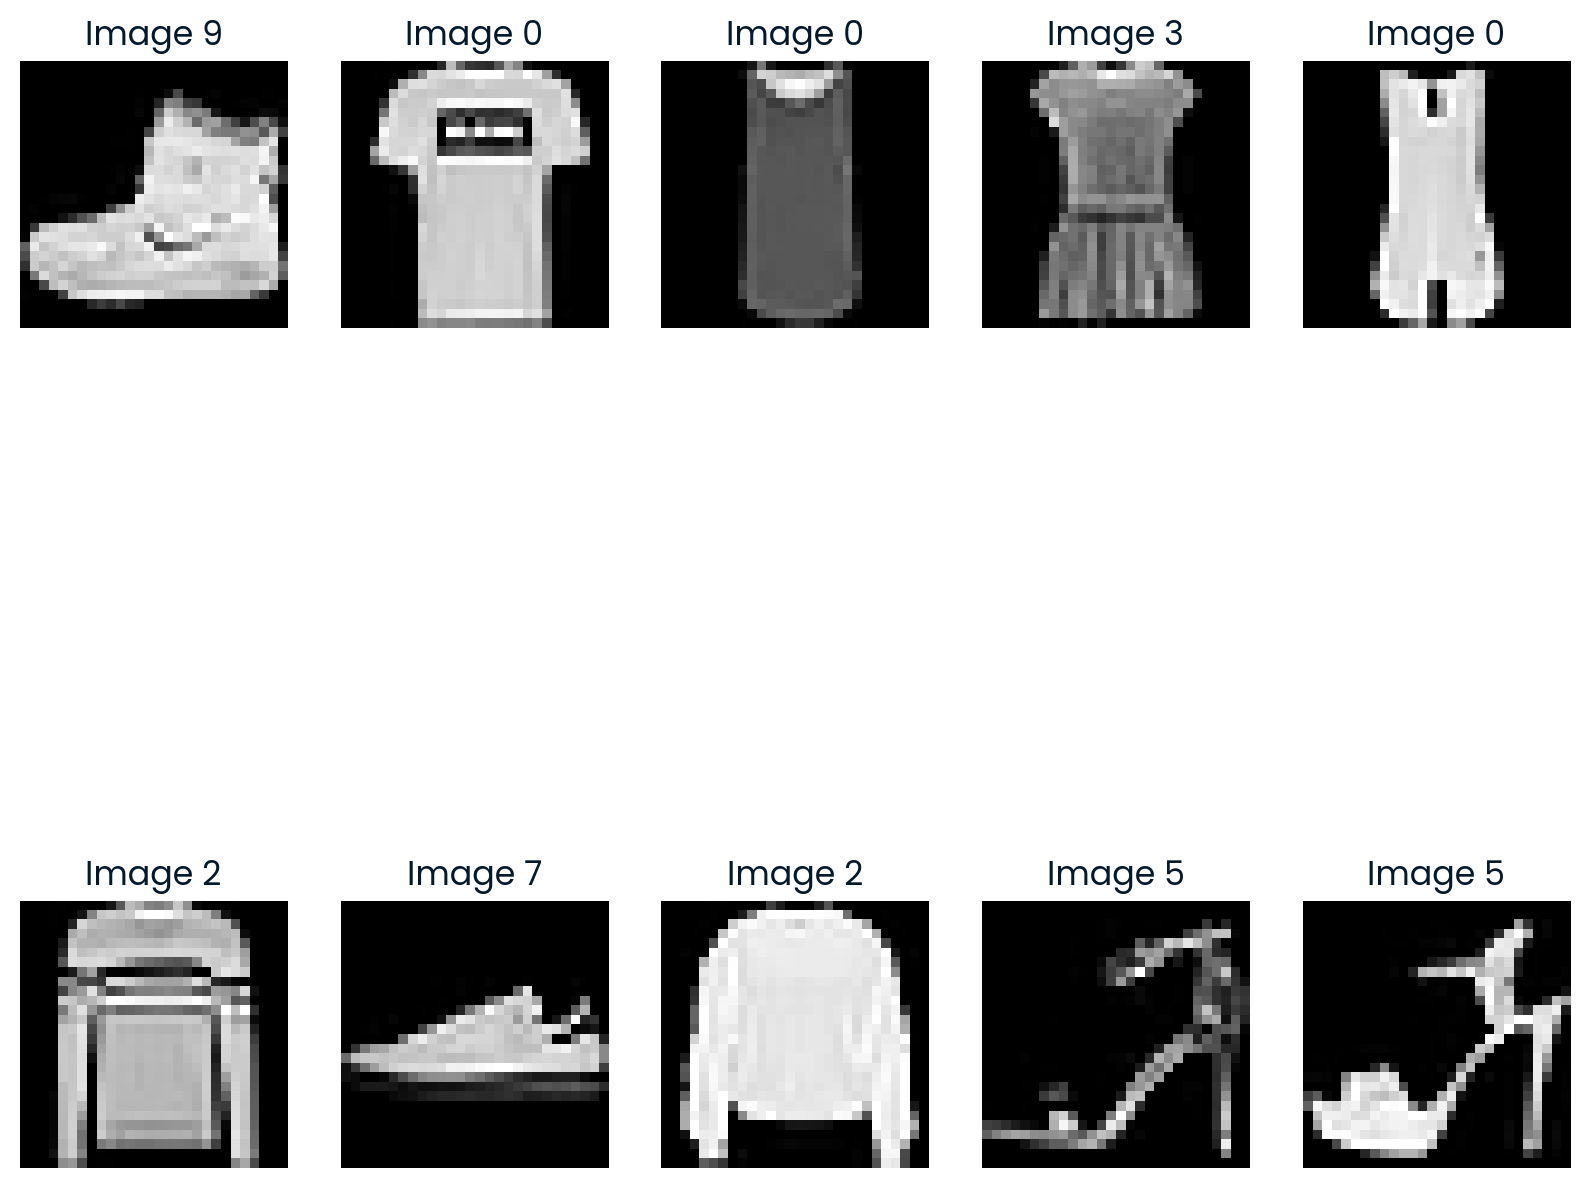

In [21]:
# Start coding here
# Use as many cells as you need

fig, axes = plt.subplots(2, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    
    # 1. Load image
    img, target = x_train[i], np.argmax(y_train[i])
    
    # 2. Plot image with Matplotlib
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Image {target}")
    ax.axis('off') # Hides the axes for cleaner visualization

In [22]:
# Definimos el factor de regularización L2 (un valor típico es 1e-4 o 1e-3)
l2_penalty = regularizers.l2(1e-4)

# 2. Definir la arquitectura del modelo con REGULARIZACIÓN
print("Construyendo el modelo con regularización L2 y Dropout...")
model = Sequential([
    # Bloque 1: Convolución (con L2) -> BN -> Activación -> Pooling -> Dropout
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2_penalty, input_shape=(28, 28, 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Apaga aleatoriamente el 25% de las neuronas en este paso
    
    # Bloque 2: Convolución (con L2) -> BN -> Activación -> Pooling -> Dropout
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2_penalty),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Bloque 3: Convolución (con L2) -> BN -> Activación
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2_penalty),
    BatchNormalization(),
    Activation('relu'),
    
    # Global Pooling
    GlobalAveragePooling2D(),
    
    # Capas Densas (Clasificador con L2 y Dropout más fuerte)
    Dense(128, kernel_regularizer=l2_penalty),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5), # Apaga el 50% en la capa densa antes de la decisión final
    
    # Capa de salida
    Dense(10),
    Activation('softmax')
])

Construyendo el modelo con regularización L2 y Dropout...


In [23]:
# 3. Compilar el modelo con las nuevas métricas
# Usamos 'categorical_crossentropy' porque las etiquetas ya no son enteros (sparse)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar un resumen de la arquitectura construida
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,882 (437.04 KB)

 Trainable params: 111,178 (434.29 KB)

 Non-trainable params: 704 (2.75 KB)

In [11]:
# 4. Configurar el callback de Early Stopping
# Monitoriza la pérdida de validación. Si no mejora en 3 épocas ('patience'), se detiene.
# 'restore_best_weights=True' asegura que nos quedemos con el mejor modelo, no el de la última época.
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

# 5. Entrenar el modelo
print("Iniciando el entrenamiento...")
# Configuramos 20 épocas como máximo (basado en "clasificar 20")
historia = model.fit(
    x_train, y_train,
    epochs=20, 
    validation_split=0.2, # Usa el 20% de los datos de entrenamiento para validar
    batch_size=64,
    callbacks=[early_stopping]
)

Iniciando el entrenamiento...
Epoch 1/20
353/750 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.5920 - loss: 1.2136

In [13]:
# 6. Evaluar el modelo con los datos de prueba
print("\nEvaluando el modelo con datos de test...")

metrics_results = model.evaluate(x_test, y_test, verbose=2)
accuracy = metrics_results[1]

print(f"Accuracy:  {accuracy:.4f}")


Evaluando el modelo con datos de test...
313/313 - 3s - 11ms/step - accuracy: 0.8867 - loss: 0.3696
Accuracy:  0.8867


In [14]:
predictions_prob = model.predict(x_test)
predictions = np.argmax(predictions_prob, axis=1)

real = np.argmax(y_test, axis=1)

# 1. Calcular precisión y recall individual por clase
precision = precision_score(real, predictions, average=None)
recall = recall_score(real, predictions, average=None)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
